# 01 – Exploratory Data Analysis (EDA)

**Goal:** Understand the Big Five personality dataset, find data quality
issues and produce a cleaned dataset for modeling.

- **Input:** `data/data.csv` (download link in the README)
- **Output:** `data/clean.csv` (not committed to Git)
- **Task:** supervised multi-class classification of the personality
  `target` (4 classes)

No random operations are used in this notebook. All later notebooks use
`random_state=42`.

> Run this notebook from the `notebooks/` folder so that the relative
> paths resolve correctly.

## 1. Load the data

In [1]:
from pathlib import Path

import pandas as pd

# Paths are relative to the notebooks/ folder
DATA_PATH = Path("../data/data.csv")
CLEAN_DATA_PATH = Path("../data/clean.csv")

# Column groups used throughout the analysis
QUESTION_COLUMNS = [
    "N1", "N2", "N3", "N4", "N5", "N6", "N7", "N8", "N9", "N10",
    "E1", "E3", "E4", "E5", "E7", "E9", "E10",
    "A4", "C4",
]
DEMOGRAPHIC_COLUMNS = ["age", "gender", "hand"]
TARGET_COLUMN = "target"

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 19,719 | Columns: 23


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate


The 19 questions are a subset of the original 50 Big Five (OCEAN)
items. The letter in the column name is the personality trait:

| Prefix | Trait | Number of items |
| --- | --- | --- |
| `N` | Neuroticism | 10 |
| `E` | Extraversion | 7 |
| `A` | Agreeableness | 1 |
| `C` | Conscientiousness | 1 |

Each answer is on a scale from 1 (*does not apply*) to 5 (*applies*).

## 2. Structure of the dataset

In [3]:
expected_columns = set(QUESTION_COLUMNS + DEMOGRAPHIC_COLUMNS
                       + [TARGET_COLUMN])
assert len(QUESTION_COLUMNS) == 19
assert set(raw_df.columns) == expected_columns, "Unexpected columns"
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19719 entries, 0 to 19718
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   N6      19719 non-null  int64
 1   N8      19719 non-null  int64
 2   N7      19719 non-null  int64
 3   N1      19719 non-null  int64
 4   N9      19719 non-null  int64
 5   N10     19719 non-null  int64
 6   N3      19719 non-null  int64
 7   N5      19719 non-null  int64
 8   E3      19719 non-null  int64
 9   N2      19719 non-null  int64
 10  E5      19719 non-null  int64
 11  N4      19719 non-null  int64
 12  E7      19719 non-null  int64
 13  E4      19719 non-null  int64
 14  age     19719 non-null  int64
 15  C4      19719 non-null  int64
 16  E1      19719 non-null  int64
 17  A4      19719 non-null  int64
 18  E10     19719 non-null  int64
 19  E9      19719 non-null  int64
 20  gender  19695 non-null  str  
 21  hand    19619 non-null  str  
 22  target  19719 non-null  str  
dtypes: int64(20), str(3)
m

In [4]:
print("Target classes:", sorted(raw_df[TARGET_COLUMN].unique()))
print("Gender values:", raw_df["gender"].unique().tolist())
print("Hand values:", raw_df["hand"].unique().tolist())

Target classes: ['Moderate', 'Overcontroller', 'Resilient', 'Undercontroller']
Gender values: ['Male', 'Female', 'Other', nan]
Hand values: ['Right', 'Both', 'Left', nan]


## 3. Data quality

This section only **diagnoses** problems. Nothing is removed yet. The
cleaning decisions are made in section 6.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 3.1 Missing values

In [6]:
missing = raw_df.isna().sum()
print(missing[missing > 0])
rows_with_missing = raw_df.isna().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_missing}")

gender     24
hand      100
dtype: int64

Rows with at least one missing value: 120


### 3.2 Duplicate rows

In [7]:
n_duplicates = raw_df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 3


### 3.3 Question scores outside the valid range 1–5

In [8]:
invalid_scores = ~raw_df[QUESTION_COLUMNS].isin([1, 2, 3, 4, 5])
invalid_per_column = invalid_scores.sum()
print(invalid_per_column[invalid_per_column > 0])
rows_with_invalid_score = invalid_scores.any(axis=1).sum()
print(f"\nRows with at least one invalid score: {rows_with_invalid_score}")

all_scores = pd.Series(raw_df[QUESTION_COLUMNS].to_numpy().ravel())
print("\nValue counts over all answers:")
print(all_scores.value_counts().sort_index())

N1     1
N2     1
N3     1
N4     1
N5     1
N6     1
N7     1
N8     1
N9     1
N10    1
E1     1
E3     1
E4     1
E5     1
E7     1
E9     1
E10    1
A4     1
C4     1
dtype: int64

Rows with at least one invalid score: 1

Value counts over all answers:
0       19
1    52001
2    76600
3    82454
4    91044
5    72543
Name: count, dtype: int64


### 3.4 Age

In [9]:
print(raw_df["age"].describe())

implausible_age = raw_df[raw_df["age"] > 100]["age"]
birth_year_like = raw_df["age"].between(1900, 2100)
print(f"\nRows with age > 100: {len(implausible_age)}")
print(f"  of which look like a birth year (1900-2100): "
      f"{birth_year_like.sum()}")
largest_values = [int(v) for v in sorted(implausible_age.unique())[-3:]]
print(f"  largest values: {largest_values}")

count    1.971900e+04
mean     5.076703e+04
std      7.121272e+06
min      1.300000e+01
25%      1.800000e+01
50%      2.200000e+01
75%      3.100000e+01
max      1.000000e+09
Name: age, dtype: float64

Rows with age > 100: 83
  of which look like a birth year (1900-2100): 73
  largest values: [2000, 412434, 999999999]


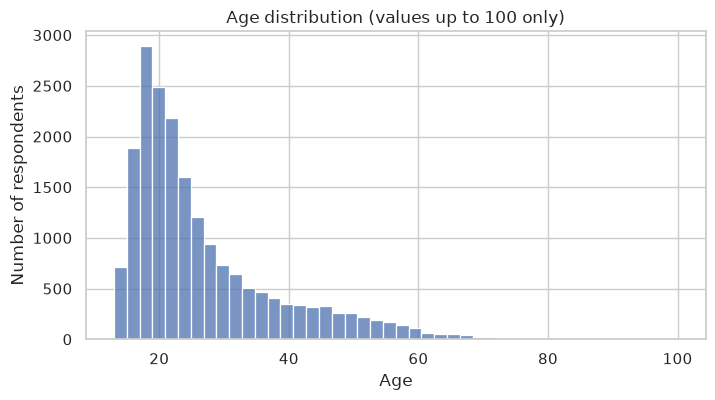

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(raw_df[raw_df["age"] <= 100]["age"], binwidth=2, ax=ax)
ax.set_title("Age distribution (values up to 100 only)")
ax.set_xlabel("Age")
ax.set_ylabel("Number of respondents")
plt.show()

In [11]:
issue_summary = pd.DataFrame(
    {
        "issue": [
            "Missing gender or hand",
            "Duplicate rows",
            "Score outside 1-5",
            "Age above 100 (birth years, typos)",
        ],
        "affected_rows": [
            rows_with_missing,
            n_duplicates,
            rows_with_invalid_score,
            len(implausible_age),
        ],
    }
)
issue_summary

,issue,affected_rows
0,Missing gender or hand,120
1,Duplicate rows,3
2,Score outside 1-5,1
3,"Age above 100 (birth years, typos)",83


**Findings**

- `gender` (24) and `hand` (100) contain missing values, affecting 120 rows.
- One row consists only of the score `0` in all 19 questions, which is
  impossible on a 1–5 scale.
- `age` contains typical entry errors: many respondents typed their
  **birth year** (e.g. 1997) and there are absurd values such as
  `999999999`. Since the survey date is unknown, a birth year cannot be
  converted into an age reliably.
- A handful of exact duplicates exist.
- All affected rows together are only about 1 % of the data.

## 4. Univariate analysis

For the plots in sections 4 and 5, a **preliminary filter** removes rows
with missing values, invalid scores and implausible ages. The actual
cleaning (and its documentation) happens in section 6.

In [12]:
MIN_AGE = 13
MAX_AGE = 100

plot_df = raw_df.dropna()
valid_scores = plot_df[QUESTION_COLUMNS].isin([1, 2, 3, 4, 5]).all(axis=1)
valid_age = plot_df["age"].between(MIN_AGE, MAX_AGE)
plot_df = plot_df[valid_scores & valid_age]
print(f"Rows used for plots: {len(plot_df):,}")

Rows used for plots: 19,517


### 4.1 Target distribution

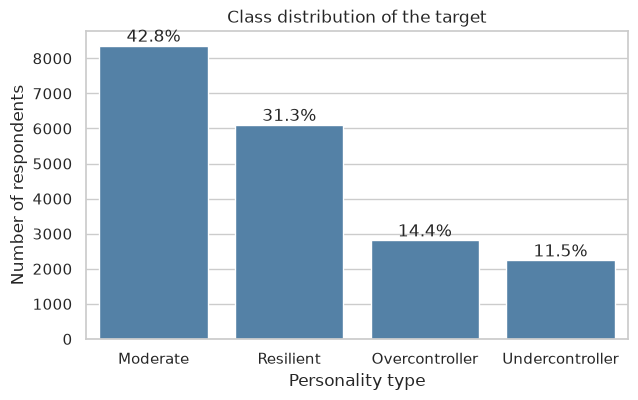

In [13]:
target_counts = plot_df[TARGET_COLUMN].value_counts()
target_share = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=target_counts.index, y=target_counts.values,
            color="steelblue", ax=ax)
for position, (count, share) in enumerate(
        zip(target_counts.values, target_share.values)):
    ax.text(position, count, f"{share:.1f}%", ha="center", va="bottom")
ax.set_title("Class distribution of the target")
ax.set_xlabel("Personality type")
ax.set_ylabel("Number of respondents")
plt.show()

The classes are **imbalanced**: *Moderate* is the largest class
(about 43 %), followed by *Resilient* (31 %), *Overcontroller* (14 %) and
*Undercontroller* (12 %).

A model that always predicts *Moderate* would reach about 43 % accuracy but
an `f1_macro` of only about 0.15. Accuracy alone is therefore misleading.
We use **`f1_macro`** as the main metric, which weights all classes equally,
and we split the data in a **stratified** way.

### 4.2 Demographics

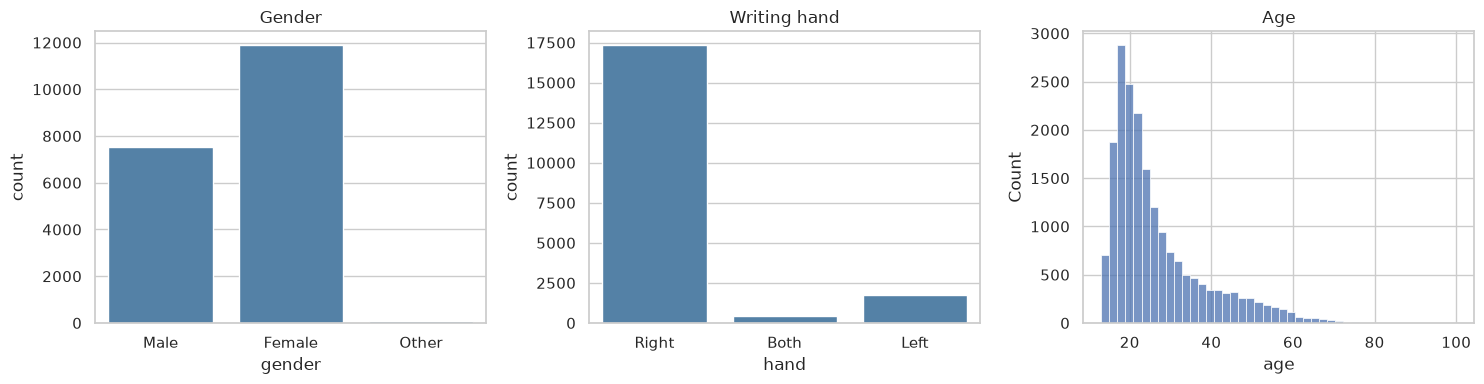

gender
Female    0.609
Male      0.386
Other     0.005
Name: proportion, dtype: float64
hand
Right    0.888
Left     0.088
Both     0.024
Name: proportion, dtype: float64
count    19517.0
mean        26.2
std         11.5
min         13.0
25%         18.0
50%         22.0
75%         31.0
max        100.0
Name: age, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=plot_df, x="gender", color="steelblue", ax=axes[0])
axes[0].set_title("Gender")

sns.countplot(data=plot_df, x="hand", color="steelblue", ax=axes[1])
axes[1].set_title("Writing hand")

sns.histplot(data=plot_df, x="age", binwidth=2, ax=axes[2])
axes[2].set_title("Age")

fig.tight_layout()
plt.show()

print(plot_df["gender"].value_counts(normalize=True).round(3))
print(plot_df["hand"].value_counts(normalize=True).round(3))
print(plot_df["age"].describe().round(1))

- About 61 % of the respondents are female, 39 % male and only about
  0.5 % are in the category *Other*.
- About 89 % write with the right hand, 9 % with the left hand and
  2 % with both.
- Age is strongly right-skewed: the median is 22 years, the mean 26 years,
  with a long tail of older respondents. Most respondents are young.

### 4.3 Question scores

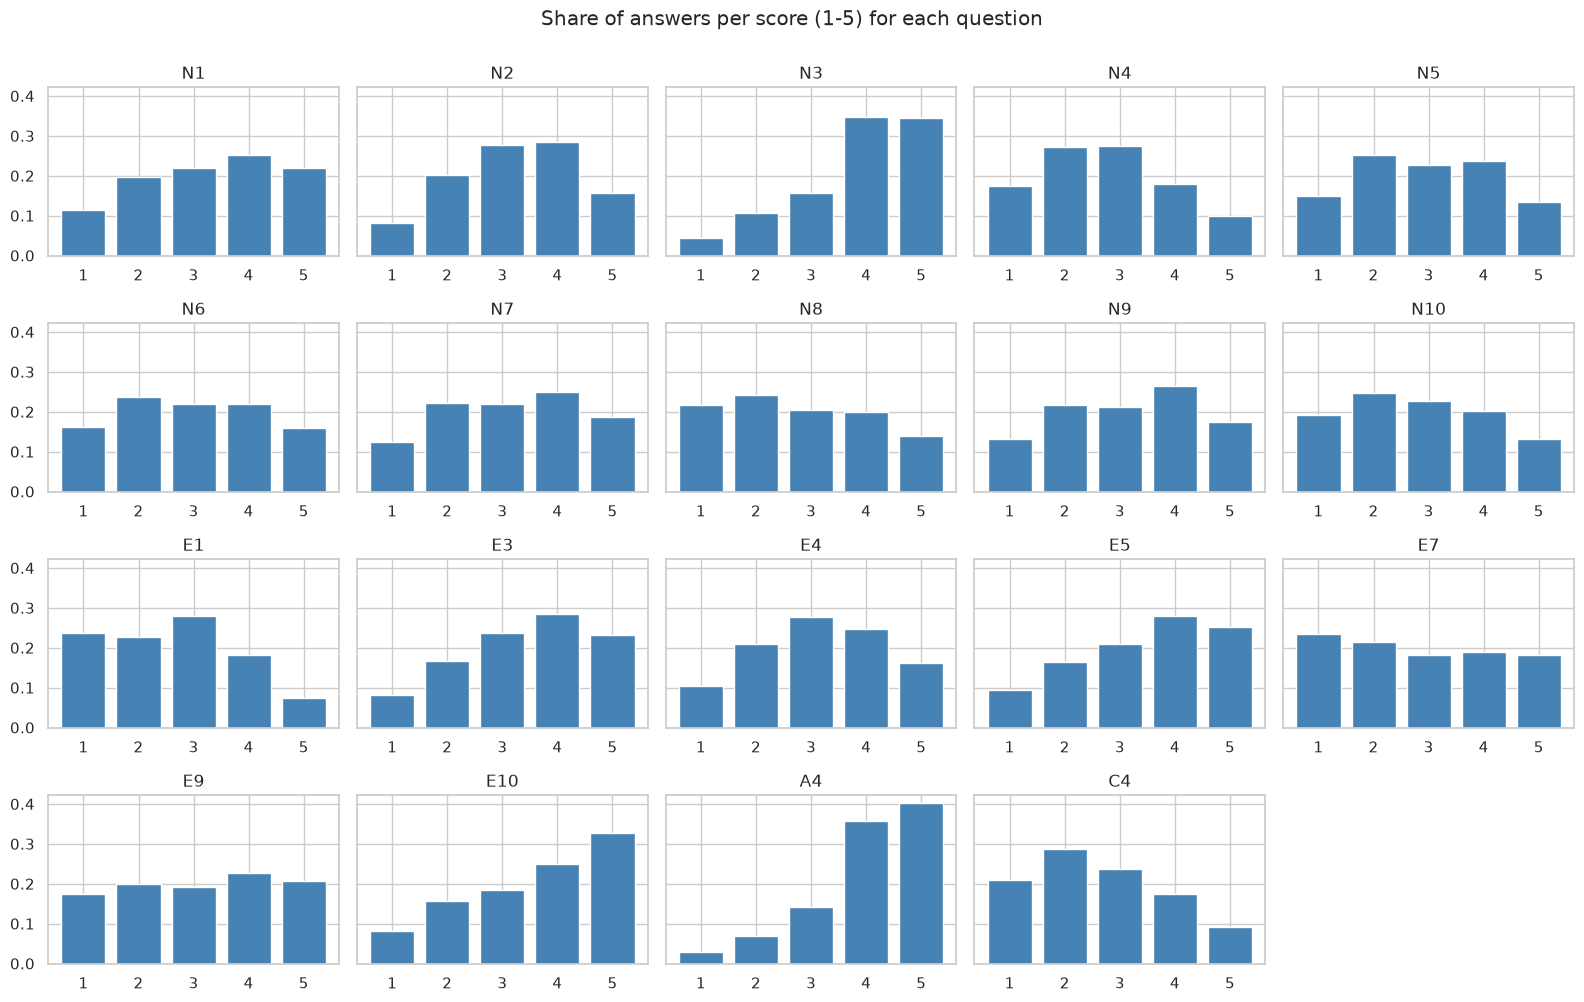

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharey=True)

for ax, column in zip(axes.ravel(), QUESTION_COLUMNS):
    shares = (plot_df[column]
              .value_counts(normalize=True)
              .reindex([1, 2, 3, 4, 5])
              .fillna(0))
    ax.bar(shares.index, shares.values, color="steelblue")
    ax.set_title(column)
    ax.set_xticks([1, 2, 3, 4, 5])

# Hide the unused subplot(s) of the 4x5 grid
for ax in axes.ravel()[len(QUESTION_COLUMNS):]:
    ax.set_visible(False)

fig.suptitle("Share of answers per score (1-5) for each question", y=1.0)
fig.tight_layout()
plt.show()

- All five answer options are used for every question, there are no
  empty categories.
- Several items are skewed: `A4` (mean about 4.0) and `N3` (about 3.8) are
  answered with high scores by most people, whereas `C4` and `E1` lean
  towards lower scores.
- The scores are ordinal (1–5). Treating them as numeric values is
  reasonable for this task.